In [3]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# File paths
processed_data_path = '../data/processed/merged_player_goalie_cps_and_salaries.csv'  # Adjust the filename
optimized_team_path = '../result/optimized_team.csv'

# Load datasets
df_processed = pd.read_csv(processed_data_path)
df_optimized = pd.read_csv(optimized_team_path)

# Display the first few rows of each dataset
print("Processed Data:")
print(df_processed.head())

print("\nOptimized Team:")
print(df_optimized.head())



Processed Data:
             player Position       cps  \
0   Nikita Kucherov        R  0.777248   
1  Nathan MacKinnon        C  0.735598   
2    Connor McDavid        C  0.690424   
3    Artemi Panarin        L  0.727521   
4    David Pastrnak        R  0.729617   

                                             url   cap_hit  cap_hit_pct  \
0  https://www.spotrac.com/nhl/player/_/id/11249   9500000        10.80   
1  https://www.spotrac.com/nhl/player/_/id/13403  12600000        14.32   
2  https://www.spotrac.com/nhl/player/_/id/17891  12500000        14.20   
3  https://www.spotrac.com/nhl/player/_/id/17517  11642857        13.23   
4  https://www.spotrac.com/nhl/player/_/id/15582  11250000        12.78   

  base_salary signing_bonus  contract_start_year  contract_years_signed  ...  \
0     5000000       4000000                 2019                      8  ...   
1      775000      15725000                 2023                      8  ...   
2     3000000       7000000             

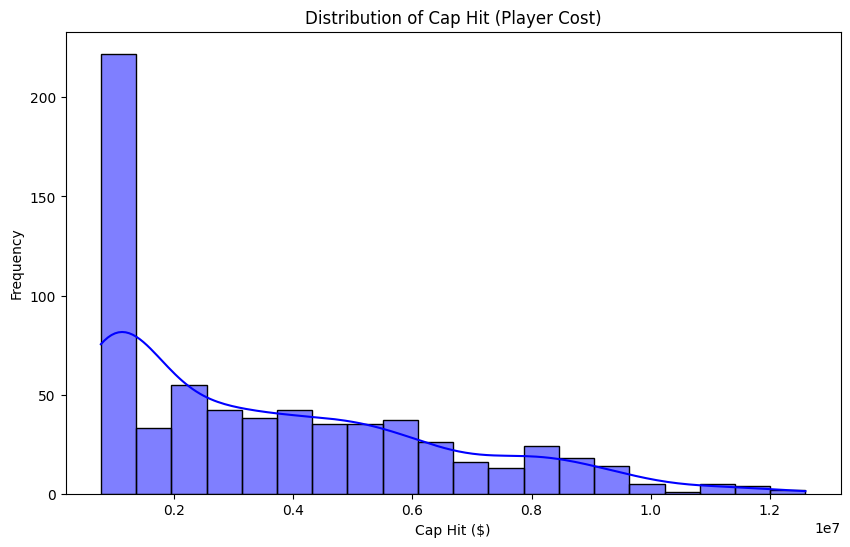

In [6]:
# Distribution of Cap Hit (Player Cost) in Processed Data
plt.figure(figsize=(10, 6))
sns.histplot(df_processed['cap_hit'], kde=True, color='blue', bins=20)
plt.title('Distribution of Cap Hit (Player Cost)')
plt.xlabel('Cap Hit ($)')
plt.ylabel('Frequency')
plt.show()



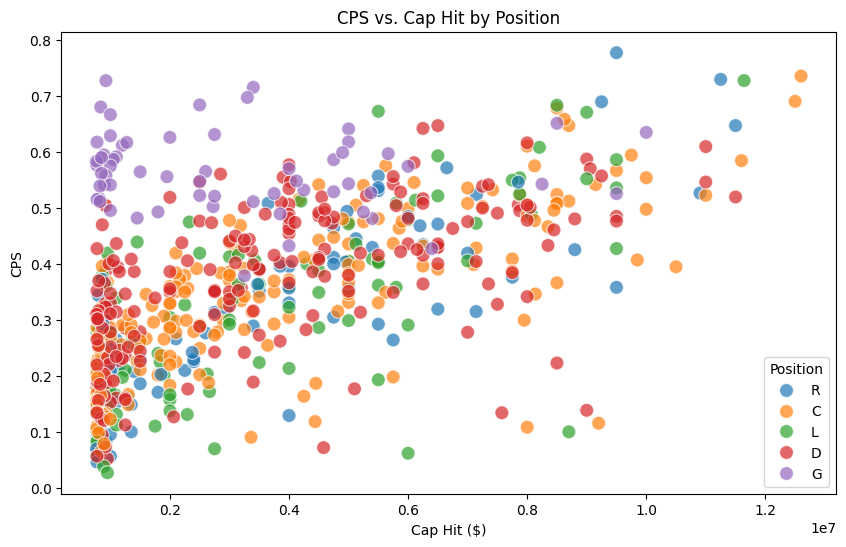

In [7]:
# Scatter Plot for CPS vs. Cap Hit
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_processed, x='cap_hit', y='cps', hue='Position', s=100, alpha=0.7)
plt.title('CPS vs. Cap Hit by Position')
plt.xlabel('Cap Hit ($)')
plt.ylabel('CPS')
plt.legend(title='Position')
plt.show()


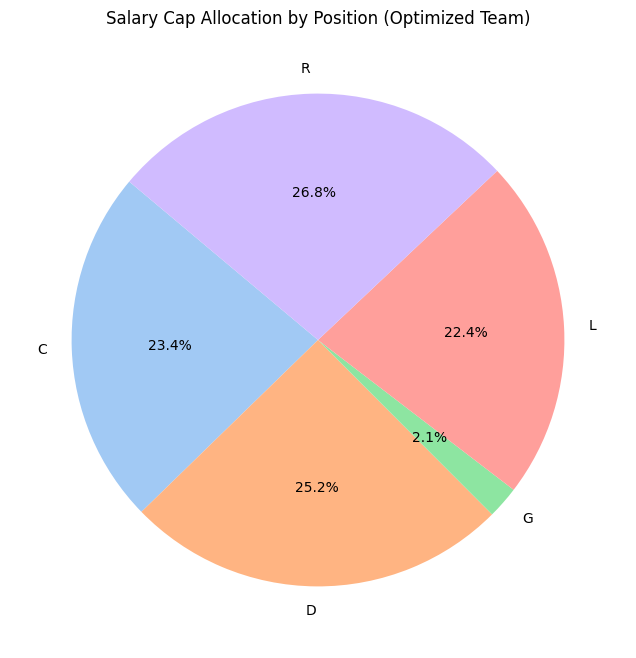

In [8]:
# Salary Cap Allocation in Optimized Team
position_budget = df_optimized.groupby('Position')['Cap Hit'].sum()

plt.figure(figsize=(8, 8))
plt.pie(position_budget, labels=position_budget.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Salary Cap Allocation by Position (Optimized Team)')
plt.show()


In [9]:
# Display the Optimized Team as a Table
df_optimized_styled = df_optimized[['Player', 'Position', 'CPS', 'Cap Hit']].style.format({
    'CPS': '{:.2f}',
    'Cap Hit': '${:.2f}'
}).background_gradient(subset=['CPS'], cmap='Greens')

df_optimized_styled


,Player,Position,CPS,Cap Hit
0,Nikita Kucherov,R,0.78,$9500000.00
1,Leon Draisaitl,C,0.68,$8500000.00
2,Mikko Rantanen,R,0.69,$9250000.00
3,Filip Forsberg,L,0.68,$8500000.00
4,Zach Hyman,L,0.67,$5500000.00
5,Vincent Trocheck,C,0.58,$5625000.00
6,Ryan O'Reilly,C,0.54,$4500000.00
7,Wyatt Johnston,C,0.51,$894167.00
8,Frank Vatrano,R,0.51,$3650000.00
9,Alexis Lafrenière,L,0.48,$2325000.00


In [10]:
fig = px.scatter(df_processed, 
                 x='cap_hit', 
                 y='cps', 
                 color='Position',
                 hover_name='player',
                 size='cap_hit',
                 title='Interactive CPS vs. Cap Hit')
fig.show()
